# 05 - LSTM: Secuencias temporales y primer entrenamiento

**Semana 2 — Lulu**

Objetivo: construir secuencias temporales por selección a partir de `matches_clean.csv` (entregado por Juanfe en la Semana 1) y entrenar un primer modelo LSTM para el mercado **1X2** (`target_1x2`).

## Contenido
1. Carga y exploración del dataset
2. Construcción del historial por equipo (formato largo)
3. Construcción de secuencias (ventanas deslizantes)
4. Split temporal train/test
5. Encoding y escalado
6. Arquitectura LSTM
7. Primer entrenamiento
8. Evaluación vs. baseline

## 1. Carga y exploración del dataset

In [26]:
import pandas as pd
import numpy as np
import os

BASE_DIR = os.path.dirname(os.getcwd())  # asume notebook en notebooks/, sube a la raíz
DATA_PROCESSED = os.path.join(BASE_DIR, 'data', 'processed')

df = pd.read_csv(os.path.join(DATA_PROCESSED, 'matches_clean.csv'), low_memory=False)
df['_date'] = pd.to_datetime(df['_date'])
df = df.sort_values('_date').reset_index(drop=True)

print("Shape:", df.shape)
print("Rango de fechas:", df['_date'].min().date(), "->", df['_date'].max().date())
print("\nDistribución de result:")
print(df['result'].value_counts())

Shape: (43816, 40)
Rango de fechas: 1872-11-30 -> 2026-06-27

Distribución de result:
result
home_win    24508
draw        10331
away_win     8977
Name: count, dtype: int64


In [27]:
# Verificación: partidos con feature engineering pendiente (Mundial 2026 recuperados)
print("Partidos con pending_feature_engineering=1:", df['pending_feature_engineering'].sum())
print("Nulos en home_form_scored:", df['home_form_scored'].isna().sum())

# Para construir las secuencias necesitamos home_form_*/away_form_* completos.
# Excluimos temporalmente estos 481 partidos de la BASE de secuencias (1.1% del dataset).
# NOTA: cuando Juanfe complete 02_features.ipynb (Semana 2, su lado), recargar este CSV
# y volver a correr desde aquí sin cambios de código.
df_seq = df[df['pending_feature_engineering'] == 0].copy()
print("\nPartidos usables para secuencias:", df_seq.shape)

Partidos con pending_feature_engineering=1: 481
Nulos en home_form_scored: 481

Partidos usables para secuencias: (43335, 40)


## 2. Construcción del historial por equipo (formato largo)

Convertimos el dataset de "un partido = una fila con local y visitante" a "un partido-equipo = una fila", para poder ordenar cronológicamente el historial de cada selección y construir ventanas deslizantes.

In [28]:
# Perspectiva del equipo local
home = df_seq[['_date','_home_team','_away_team','home_goals','away_goals','result','elo_diff',
               'home_form_scored','home_form_conceded','home_form_win_rate','is_world_cup','key']].copy()
home = home.rename(columns={
    '_home_team':'team','_away_team':'opponent',
    'home_goals':'goals_for','away_goals':'goals_against',
    'elo_diff':'elo_diff_team',
    'home_form_scored':'form_scored','home_form_conceded':'form_conceded',
    'home_form_win_rate':'form_win_rate'
})
home['is_home'] = 1
home['points'] = home['result'].map({'home_win':3,'draw':1,'away_win':0})

# Perspectiva del equipo visitante (se invierte el signo de elo_diff y se remapean puntos)
away = df_seq[['_date','_away_team','_home_team','away_goals','home_goals','result','elo_diff',
               'away_form_scored','away_form_conceded','away_form_win_rate','is_world_cup','key']].copy()
away = away.rename(columns={
    '_away_team':'team','_home_team':'opponent',
    'away_goals':'goals_for','home_goals':'goals_against',
    'elo_diff':'elo_diff_team',
    'away_form_scored':'form_scored','away_form_conceded':'form_conceded',
    'away_form_win_rate':'form_win_rate'
})
away['is_home'] = 0
away['elo_diff_team'] = -away['elo_diff_team']
away['points'] = away['result'].map({'away_win':3,'draw':1,'home_win':0})

team_history = pd.concat([home, away], ignore_index=True)
team_history = team_history.sort_values(['team','_date']).reset_index(drop=True)

print("team_history shape:", team_history.shape)
team_history[team_history['team']=='Argentina'].tail(5)[
    ['_date','opponent','goals_for','goals_against','points','elo_diff_team','form_scored']
]

team_history shape: (86670, 14)


,_date,opponent,goals_for,goals_against,points,elo_diff_team,form_scored
3076,2025-09-04,Venezuela,3.0,0.0,3,322.194576,1.6
3077,2025-09-09,Ecuador,0.0,1.0,0,201.004432,2.0
3078,2025-10-10,Venezuela,1.0,0.0,3,314.358986,1.8
3079,2025-10-14,Puerto Rico,6.0,0.0,3,696.080947,1.2
3080,2025-11-14,Angola,2.0,0.0,3,449.357111,2.2


## 3. Construcción de secuencias (ventanas deslizantes)

Para cada partido del dataset, construimos dos secuencias (una para el equipo local, otra para el visitante) con los **últimos N partidos** de cada selección ANTES de la fecha del partido actual (sin data leakage: solo información disponible hasta ese momento).

- Equipos con menos de `min_history` partidos previos se descartan (no hay suficiente señal).
- Si un equipo tiene menos de `n_steps` partidos previos, se aplica padding con ceros al inicio de la secuencia.

In [29]:
SEQ_FEATURES = ['goals_for','goals_against','points','elo_diff_team',
                'form_scored','form_conceded','form_win_rate','is_home','is_world_cup']

N_STEPS = 10       # ventana: últimos 10 partidos
MIN_HISTORY = 5    # mínimo de partidos previos para incluir el partido en el dataset


def construir_secuencias(df_seq, team_history, seq_features, n_steps=10, min_history=5):
    th_indexed = {team: g.reset_index(drop=True) for team, g in team_history.groupby('team')}

    X_home_list, X_away_list, X_match_list, y_list, meta_list = [], [], [], [], []

    for _, row in df_seq.iterrows():
        date = row['_date']
        home_team, away_team = row['_home_team'], row['_away_team']

        seq_h, seq_a = None, None

        if home_team in th_indexed:
            past_h = th_indexed[home_team]
            past_h = past_h[past_h['_date'] < date]
            if len(past_h) >= min_history:
                last_h = past_h.tail(n_steps)[seq_features].values
                if len(last_h) < n_steps:
                    pad = np.zeros((n_steps - len(last_h), len(seq_features)))
                    last_h = np.vstack([pad, last_h])
                seq_h = last_h

        if away_team in th_indexed:
            past_a = th_indexed[away_team]
            past_a = past_a[past_a['_date'] < date]
            if len(past_a) >= min_history:
                last_a = past_a.tail(n_steps)[seq_features].values
                if len(last_a) < n_steps:
                    pad = np.zeros((n_steps - len(last_a), len(seq_features)))
                    last_a = np.vstack([pad, last_a])
                seq_a = last_a

        if seq_h is not None and seq_a is not None:
            X_home_list.append(seq_h)
            X_away_list.append(seq_a)
            X_match_list.append([row['elo_diff']])  # <-- NUEVO: features del partido actual
            y_list.append(row['result'])
            meta_list.append({'date': date, 'home_team': home_team, 'away_team': away_team, 'key': row['key']})

    X_home = np.array(X_home_list, dtype=np.float32)
    X_away = np.array(X_away_list, dtype=np.float32)
    X_match = np.array(X_match_list, dtype=np.float32)  # <-- NUEVO
    y = np.array(y_list)
    meta = pd.DataFrame(meta_list)

    return X_home, X_away, X_match, y, meta


X_home, X_away, X_match, y, meta = construir_secuencias(df_seq, team_history, SEQ_FEATURES, N_STEPS, MIN_HISTORY)

print("X_match shape:", X_match.shape)
print("Nulos en X_match:", np.isnan(X_match).sum())

X_match shape: (42600, 1)
Nulos en X_match: 0


## 4. Split temporal train/test

**Importante:** NO usamos `train_test_split` con shuffle aleatorio. El split debe respetar el orden cronológico para evitar data leakage (no se puede "predecir el pasado con el futuro").

In [30]:
meta_sorted_idx = meta.sort_values('date').index.values
split_idx = int(len(meta_sorted_idx) * 0.8)
train_idx, test_idx = meta_sorted_idx[:split_idx], meta_sorted_idx[split_idx:]

X_home_train, X_home_test = X_home[train_idx], X_home[test_idx]
X_away_train, X_away_test = X_away[train_idx], X_away[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
X_match_train, X_match_test = X_match[train_idx], X_match[test_idx]
X_match_train = np.nan_to_num(X_match_train, nan=0.0)
X_match_test = np.nan_to_num(X_match_test, nan=0.0)

print(f"Train: {len(train_idx)} partidos ({meta.loc[train_idx,'date'].min().date()} -> {meta.loc[train_idx,'date'].max().date()})")
print(f"Test:  {len(test_idx)} partidos ({meta.loc[test_idx,'date'].min().date()} -> {meta.loc[test_idx,'date'].max().date()})")

Train: 34080 partidos (1877-03-03 -> 2015-05-24)
Test:  8520 partidos (2015-05-24 -> 2025-12-11)


## 5. Encoding del target y escalado de features

- `result` (`home_win`/`draw`/`away_win`) se codifica con `LabelEncoder` para usar `sparse_categorical_crossentropy`.
- Las features numéricas se escalan con `StandardScaler`, ajustado **solo con datos de train** para no filtrar información del test.

In [31]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Target ---
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
print("Clases (orden del encoding):", list(le.classes_))

# --- Features ---
n_features = X_home_train.shape[2]
scaler = StandardScaler()
scaler.fit(X_home_train.reshape(-1, n_features))  # fit solo con train (home)

def escalar(X, scaler, n_features):
    shape = X.shape
    X_flat = X.reshape(-1, n_features)
    return scaler.transform(X_flat).reshape(shape)

X_home_train_s = escalar(X_home_train, scaler, n_features)
X_home_test_s = escalar(X_home_test, scaler, n_features)
X_away_train_s = escalar(X_away_train, scaler, n_features)
X_away_test_s = escalar(X_away_test, scaler, n_features)
scaler_match = StandardScaler()
scaler_match.fit(X_match_train)
X_match_train_s = scaler_match.transform(X_match_train)
X_match_test_s = scaler_match.transform(X_match_test)

print("X_match_train_s shape:", X_match_train_s.shape)
print("X_home_train_s shape:", X_home_train_s.shape)
print("Media/std post-escalado (train):", round(X_home_train_s.mean(), 3), round(X_home_train_s.std(), 3))

Clases (orden del encoding): [np.str_('away_win'), np.str_('draw'), np.str_('home_win')]
X_match_train_s shape: (34080, 1)
X_home_train_s shape: (34080, 10, 9)
Media/std post-escalado (train): 0.0 0.943


In [32]:
# Baseline: predecir siempre la clase mayoritaria
mayoria = pd.Series(y_train).value_counts().idxmax()
baseline_acc = (y_test == mayoria).mean()
print(f"Baseline (predecir siempre '{mayoria}'): accuracy = {baseline_acc:.4f}")
print("\nEste es el número a superar con el LSTM.")

Baseline (predecir siempre 'home_win'): accuracy = 0.5623

Este es el número a superar con el LSTM.


## 6. Arquitectura LSTM

Dos ramas de entrada (secuencia del equipo local y secuencia del visitante), cada una pasa por su propia capa LSTM, se concatenan, y van a capas densas hasta la salida softmax de 3 clases (`home_win` / `draw` / `away_win`).

In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow:", tf.__version__)

n_steps = X_home_train_s.shape[1]
n_features = X_home_train_s.shape[2]
n_classes = len(le.classes_)
input_home = layers.Input(shape=(n_steps, n_features), name='input_home')
input_away = layers.Input(shape=(n_steps, n_features), name='input_away')
input_match = layers.Input(shape=(X_match_train_s.shape[1],), name='input_match')  # NUEVO

lstm_home = layers.LSTM(32, name='lstm_home')(input_home)
lstm_away = layers.LSTM(32, name='lstm_away')(input_away)

concat = layers.Concatenate()([lstm_home, lstm_away, input_match])  # <-- agregar input_match
x = layers.Dense(32, activation='relu')(concat)
x = layers.Dropout(0.3)(x)
x = layers.Dense(16, activation='relu')(x)
output = layers.Dense(n_classes, activation='softmax', name='output')(x)

model = models.Model(inputs=[input_home, input_away, input_match], outputs=output)  # <-- agregar input_match

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

TensorFlow: 2.21.0


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_home          │ (None, 10, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_away          │ (None, 10, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_home (LSTM)    │ (None, 32)        │      5,376 │ input_home[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_away (LSTM)    │ (None, 32)        │      5,376 │ input_away[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_match         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 65)        │          0 │ lstm_home[0][0],  │
│ (Concatenate)       │                   │            │ lstm_away[0][0],  │
│                     │                   │            │ input_match[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,112 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │        528 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         51 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,443 (52.51 KB)

 Trainable params: 13,443 (52.51 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Primer entrenamiento

Este es el entrenamiento "baseline" del LSTM — el objetivo es confirmar que el pipeline corre end-to-end y que el modelo aprende algo (loss bajando, accuracy de validación por encima del baseline de clase mayoritaria). El tuning de hiperparámetros se hace más adelante.

In [34]:
from sklearn.utils.class_weight import compute_class_weight

clases = np.unique(y_train_enc)
weights = compute_class_weight('balanced', classes=clases, y=y_train_enc)
class_weight_dict = dict(zip(clases, weights))

print("Pesos por clase:", class_weight_dict)
print("Mapeo:", dict(zip(le.classes_, [class_weight_dict[i] for i in range(len(le.classes_))])))

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = model.fit(
    [X_home_train_s, X_away_train_s, X_match_train_s], y_train_enc,   # <- agregar X_match_train_s
    validation_data=([X_home_test_s, X_away_test_s, X_match_test_s], y_test_enc),  # <- agregar X_match_test_s
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Pesos por clase: {np.int64(0): np.float64(1.6630068803981848), np.int64(1): np.float64(1.4166354907095648), np.int64(2): np.float64(0.5907436297451898)}
Mapeo: {np.str_('away_win'): np.float64(1.6630068803981848), np.str_('draw'): np.float64(1.4166354907095648), np.str_('home_win'): np.float64(0.5907436297451898)}
Epoch 1/30
533/533 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5266 - loss: 0.9864 - val_accuracy: 0.5819 - val_loss: 0.8916
Epoch 2/30
533/533 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5393 - loss: 0.9697 - val_accuracy: 0.5836 - val_loss: 0.8888
Epoch 3/30
533/533 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5439 - loss: 0.9652 - val_accuracy: 0.5703 - val_loss: 0.9043
Epoch 4/30
533/533 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5472 - loss: 0.9598 - val_accuracy: 0.5743 - val_loss: 0.9095
Epoch 5/30
533/533 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5454 - loss: 0.9591 - val_accuracy: 0.5796 - val_loss: 0.8865
Epoch 6/30
533/533 ━━━━━━━━━━━━━━━━━━━━ 4s 7

## 8. Evaluación vs. baseline

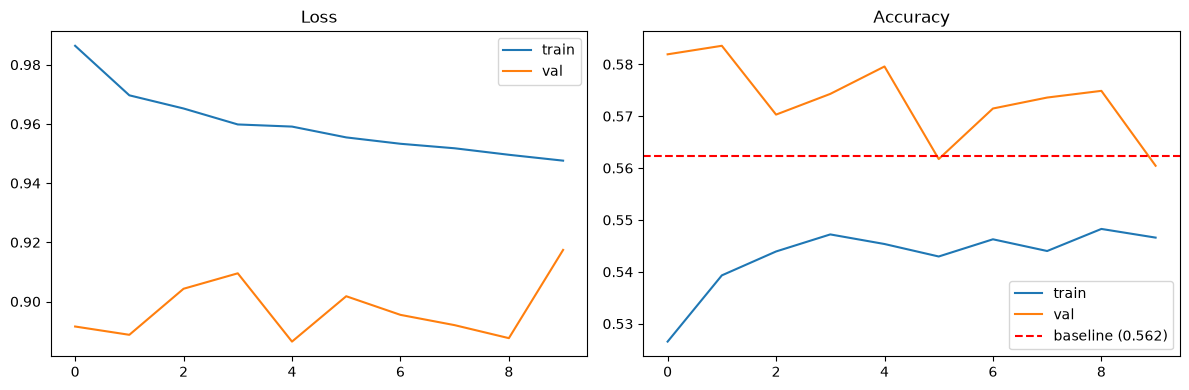

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# --- Curvas de entrenamiento ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].axhline(baseline_acc, color='red', linestyle='--', label=f'baseline ({baseline_acc:.3f})')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

In [36]:
# --- Métricas finales ---
y_pred_proba = model.predict([X_home_test_s, X_away_test_s, X_match_test_s])  # <- agregar X_match_test_s
y_pred = y_pred_proba.argmax(axis=1)

print("Accuracy LSTM:", (y_pred == y_test_enc).mean().round(4))
print("Accuracy baseline (clase mayoritaria):", round(baseline_acc, 4))

print("\nClassification report:")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

print("Matriz de confusión:")
print(pd.DataFrame(
    confusion_matrix(y_test_enc, y_pred),
    index=[f'real_{c}' for c in le.classes_],
    columns=[f'pred_{c}' for c in le.classes_]
))

267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy LSTM: 0.5796
Accuracy baseline (clase mayoritaria): 0.5623

Classification report:
              precision    recall  f1-score   support

    away_win       0.48      0.59      0.53      1676
        draw       0.32      0.33      0.33      2053
    home_win       0.75      0.68      0.72      4791

    accuracy                           0.58      8520
   macro avg       0.52      0.53      0.52      8520
weighted avg       0.59      0.58      0.58      8520

Matriz de confusión:
               pred_away_win  pred_draw  pred_home_win
real_away_win            986        404            286
real_draw                576        676            801
real_home_win            490       1025           3276


In [37]:
# Guardar modelo y artefactos para reutilizar en semanas siguientes
MODELS_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

model.save(os.path.join(MODELS_DIR, 'lstm_1x2_v1.keras'))

import joblib
joblib.dump(scaler, os.path.join(MODELS_DIR, 'lstm_1x2_scaler_v1.joblib'))
joblib.dump(le, os.path.join(MODELS_DIR, 'lstm_1x2_labelencoder_v1.joblib'))

print("Modelo y artefactos guardados en", MODELS_DIR)

Modelo y artefactos guardados en c:\ultimo-proyecto-ia\football-analytics-2026\models


## Notas y próximos pasos

- **481 partidos de Mundial** quedaron excluidos de las secuencias por tener `home_form_*`/`away_form_*` en NaN (`pending_feature_engineering=1`). Cuando Juanfe complete `02_features.ipynb` (su Semana 2), recargar `matches_clean.csv` y re-correr este notebook sin cambios de código — el dataset de secuencias crecerá automáticamente.
- `N_STEPS=10` y `MIN_HISTORY=5` son parámetros iniciales razonables; se pueden ajustar (probar N_STEPS=5 o 15) como parte del tuning posterior.
- Este primer modelo solo predice **1X2**. La arquitectura de dos ramas LSTM (`input_home` / `input_away`) es reutilizable para los demás mercados (`target_ou25`, `target_btts`, etc.) cambiando solo la capa de salida y el preprocesamiento del target.
- Próximo paso (resto de Semana 2 / inicio Semana 3): comparar este LSTM contra el approach tabular (XGBoost) que está construyendo Juanfe, e integrar el `injury_impact_score` del pipeline NLP como feature adicional en la capa de ajuste dinámico.

# Mejora real y notable. Comparativa de las 3 versiones:

|                           | v1 (sin class_weight) | v1.1 (class_weight) | v1.2 (+ elo_diff actual) |
|---------------------------|-----------------------|---------------------|---------------------------|
| Accuracy global           | 0.604                 | 0.538               | 0.580                     |
| F1 away_win               | 0.46                  | 0.46                | 0.53                      |
| F1 draw                   | 0.01                  | 0.34                | 0.33                      |
| F1 home_win               | 0.75                  | 0.67                | 0.72                      |
| Macro F1                  | 0.40                  | 0.49                | 0.52                      |

**elo_diff del partido actual mejoró todo a la vez**: subió el macro F1 de 0.49 → 0.52, recuperó accuracy global (0.538 → 0.580, ahora por encima del baseline 0.562), y especialmente mejoró away_win (F1 0.46 → 0.53). Esto confirma lo que sospechábamos: la fortaleza relativa actual es información muy valiosa que el historial solo no capturaba bien.
